# 05 — FPL Squad Optimizer

Uses Integer Linear Programming (PuLP) to:
1. **Select the optimal 15-man squad** from all available players given a £100m budget
2. **Visualise the squad** on a football pitch (mplsoccer)
3. **Recommend transfers** given a current squad and available budget
4. **Sensitivity analysis** — how does predicted value change with budget?

The optimizer uses the XGBoost predicted points from notebook 04 as its objective.

**Output:** `src/models/optimize.py` — `FPLOptimizer` class used by the Dash app.

## 1. Imports and setup

In [11]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.models.predict import FPLPredictor
from src.models.optimize import FPLOptimizer

PROCESSED = Path('../data/processed')
RAW       = Path('../data/raw')
MODELS    = Path('../models')

print('Libraries loaded.')

Libraries loaded.


## 2. Load features and generate predictions

We use the XGBoost model trained in notebook 04 to generate predicted points
for the **latest available gameweek** — these feed directly into the optimizer.

In [12]:
# Load feature data
features = pd.read_parquet(PROCESSED / 'features.parquet')
print(f'Features: {features.shape}')
print(f'Rounds available: {sorted(features["round"].unique())}')

Features: (22477, 37)
Rounds available: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]


In [13]:
# Use the most recent COMPLETE gameweek as our 'current' snapshot
# A gameweek is considered complete if it has data for at least 200 players
gw_counts = features.groupby('round').size()
complete_gws = gw_counts[gw_counts >= 200].index
latest_gw = int(complete_gws.max())
latest_df = features[features['round'] == latest_gw].copy()
print(f'Using GW{latest_gw} — {len(latest_df)} players with data')
print(f'(GW{latest_gw + 1} has only {gw_counts.get(latest_gw + 1, 0)} rows — incomplete, skipped)')

# Load trained predictor
predictor = FPLPredictor(models_dir=MODELS)
predictor.load()

# Generate predictions
latest_df['predicted_pts'] = predictor.predict(latest_df)
print(f'\nPredictions generated. Range: {latest_df["predicted_pts"].min():.2f} — {latest_df["predicted_pts"].max():.2f}')
print(f'Mean predicted pts: {latest_df["predicted_pts"].mean():.2f}')

Using GW30 — 661 players with data
(GW31 has only 2 rows — incomplete, skipped)

Predictions generated. Range: -0.31 — 11.55
Mean predicted pts: 1.17


In [14]:
# Build the player pool DataFrame the optimizer expects
# Columns needed: player_id, web_name, position, team, now_cost, predicted_pts

# Load FPL player info — only need web_name, status, team from here
fpl_players = pd.read_parquet(RAW / 'fpl_players.parquet')
POSITION_MAP = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}
fpl_players['position'] = fpl_players['element_type'].map(POSITION_MAP)
fpl_meta = fpl_players[['id', 'web_name', 'position', 'team', 'status']].rename(columns={'id': 'player_id'})

# Use latest_df for predicted_pts AND now_cost (stored as 'value' in features, already in £m)
player_pool = latest_df[['player_id', 'value', 'predicted_pts']].copy()
player_pool.rename(columns={'value': 'now_cost'}, inplace=True)

# Merge with metadata
players_df = player_pool.merge(fpl_meta, on='player_id', how='left')

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f'now_cost range:   £{players_df["now_cost"].min():.1f}m — £{players_df["now_cost"].max():.1f}m')
print(f'now_cost NaNs:    {players_df["now_cost"].isna().sum()}')
print(f'predicted NaNs:   {players_df["predicted_pts"].isna().sum()}')
print(f'position NaNs:    {players_df["position"].isna().sum()}')
print(f'\nPosition counts (before status filter):')
print(players_df['position'].value_counts())

# Drop rows with missing cost, position, or predictions
players_df = players_df.dropna(subset=['now_cost', 'position', 'predicted_pts'])
players_df = players_df[players_df['now_cost'] > 0]

# Filter to available players; fall back to full pool if too few remain
players_available = players_df[
    players_df['player_id'].isin(fpl_meta[fpl_meta['status'] == 'a']['player_id'])
].copy()

print(f'\nAfter status filter:')
print(players_available['position'].value_counts())
print(f'Total available: {len(players_available)}')

if players_available['position'].value_counts().get('GKP', 0) < 2 or \
   players_available['position'].value_counts().get('DEF', 0) < 5 or \
   players_available['position'].value_counts().get('MID', 0) < 5 or \
   players_available['position'].value_counts().get('FWD', 0) < 3:
    print('\nWARNING: Not enough players per position after status filter — using full pool')
    players_available = players_df.copy()
    print(players_available['position'].value_counts())

players_available.sort_values('predicted_pts', ascending=False).head(10)

now_cost range:   £3.7m — £14.0m
now_cost NaNs:    0
predicted NaNs:   0
position NaNs:    0

Position counts (before status filter):
position
MID    295
DEF    212
GKP     80
FWD     74
Name: count, dtype: int64

After status filter:
position
MID    172
DEF    137
GKP     53
FWD     47
Name: count, dtype: int64
Total available: 409


,player_id,now_cost,predicted_pts,web_name,position,team,status
357,449,10.1,11.550299,B.Fernandes,MID,14,a
416,508,4.7,9.849066,N.Williams,DEF,16,a
423,515,7.3,7.122819,Gibbs-White,MID,16,a
70,101,4.8,6.922252,Kelleher,GKP,5,a
265,329,6.0,6.887172,Wilson,MID,10,a
414,506,5.2,6.745564,Murillo,DEF,16,a
413,505,5.1,6.706794,Milenković,DEF,16,a
434,526,5.8,5.817723,Igor Jesus,FWD,16,a
148,178,6.1,5.784534,Welbeck,FWD,6,a
106,136,7.2,5.667863,Thiago,FWD,5,a


## 3. Select optimal squad

The ILP optimizer picks the best 15 players (2 GKP, 5 DEF, 5 MID, 3 FWD)
within a £100m budget, with max 3 players per club. Captain is chosen automatically
as the player with the highest predicted points.

In [15]:
optimizer = FPLOptimizer(budget=100.0)
result    = optimizer.select_squad(players_available, budget=100.0)

print(f'Status:           {result["status"]}')
print(f'Total cost:       £{result["total_cost"]:.1f}m')
print(f'Captain:          {result["captain"]}')
print(f'Vice-captain:     {result["vice_captain"]}')
print(f'Predicted total:  {result["predicted_total"]:.2f} pts')

Status:           Optimal
Total cost:       £94.1m
Captain:          B.Fernandes
Vice-captain:     N.Williams
Predicted total:  107.09 pts


In [16]:
squad_df = result['squad']
print('=== Optimal Squad ===')
for pos in ['GKP', 'DEF', 'MID', 'FWD']:
    pos_players = squad_df[squad_df['position'] == pos]
    print(f'\n{pos}:')
    for _, row in pos_players.iterrows():
        cap_marker = ' ©' if row.get('is_captain') else ''
        print(f'  {row["web_name"]:<20} £{row["now_cost"]:.1f}m  {row["predicted_pts"]:.2f} pts{cap_marker}')

=== Optimal Squad ===

GKP:
  Kelleher             £4.8m  6.92 pts
  Martinez             £5.1m  4.59 pts

DEF:
  N.Williams           £4.7m  9.85 pts
  Murillo              £5.2m  6.75 pts
  Collins              £4.9m  5.16 pts
  Tarkowski            £5.7m  5.00 pts
  Konsa                £4.4m  4.65 pts

MID:
  B.Fernandes          £10.1m  11.55 pts ©
  Gibbs-White          £7.3m  7.12 pts
  Wilson               £6.0m  6.89 pts
  Gordon               £7.2m  5.45 pts
  Szoboszlai           £6.9m  4.96 pts

FWD:
  Welbeck              £6.1m  5.78 pts
  Thiago               £7.2m  5.67 pts
  Watkins              £8.5m  5.20 pts


## 3b. Optimal starting XI

When playing without Bench Boost, only your 11 starters score points.
This runs a separate ILP with FPL formation rules:
- Exactly **1 GKP**
- **3–5 DEF**, **2–5 MID**, **1–3 FWD**
- Total = **11**

In [17]:
xi_result = optimizer.select_starting_xi(players_available, budget=100.0)

print(f'Status:           {xi_result["status"]}')
print(f'Formation:        {xi_result["formation"]}')
print(f'Total cost:       £{xi_result["total_cost"]:.1f}m')
print(f'Captain:          {xi_result["captain"]}')
print(f'Vice-captain:     {xi_result["vice_captain"]}')
print(f'Predicted total:  {xi_result["predicted_total"]:.2f} pts')

print('\n=== Optimal Starting XI ===')
xi_df = xi_result['xi']
for pos in ['GKP', 'DEF', 'MID', 'FWD']:
    pos_players = xi_df[xi_df['position'] == pos]
    if pos_players.empty:
        continue
    print(f'\n{pos}:')
    for _, row in pos_players.iterrows():
        cap_marker = ' ©' if row.get('is_captain') else ''
        print(f'  {row["web_name"]:<20} £{row["now_cost"]:.1f}m  {row["predicted_pts"]:.2f} pts{cap_marker}')

Status:           Optimal
Formation:        3-4-3
Total cost:       £72.0m
Captain:          B.Fernandes
Vice-captain:     N.Williams
Predicted total:  87.89 pts

=== Optimal Starting XI ===

GKP:
  Kelleher             £4.8m  6.92 pts

DEF:
  N.Williams           £4.7m  9.85 pts
  Murillo              £5.2m  6.75 pts
  Collins              £4.9m  5.16 pts

MID:
  B.Fernandes          £10.1m  11.55 pts ©
  Gibbs-White          £7.3m  7.12 pts
  Wilson               £6.0m  6.89 pts
  Gordon               £7.2m  5.45 pts

FWD:
  Welbeck              £6.1m  5.78 pts
  Thiago               £7.2m  5.67 pts
  Watkins              £8.5m  5.20 pts


## 4. Visualise squad on a pitch

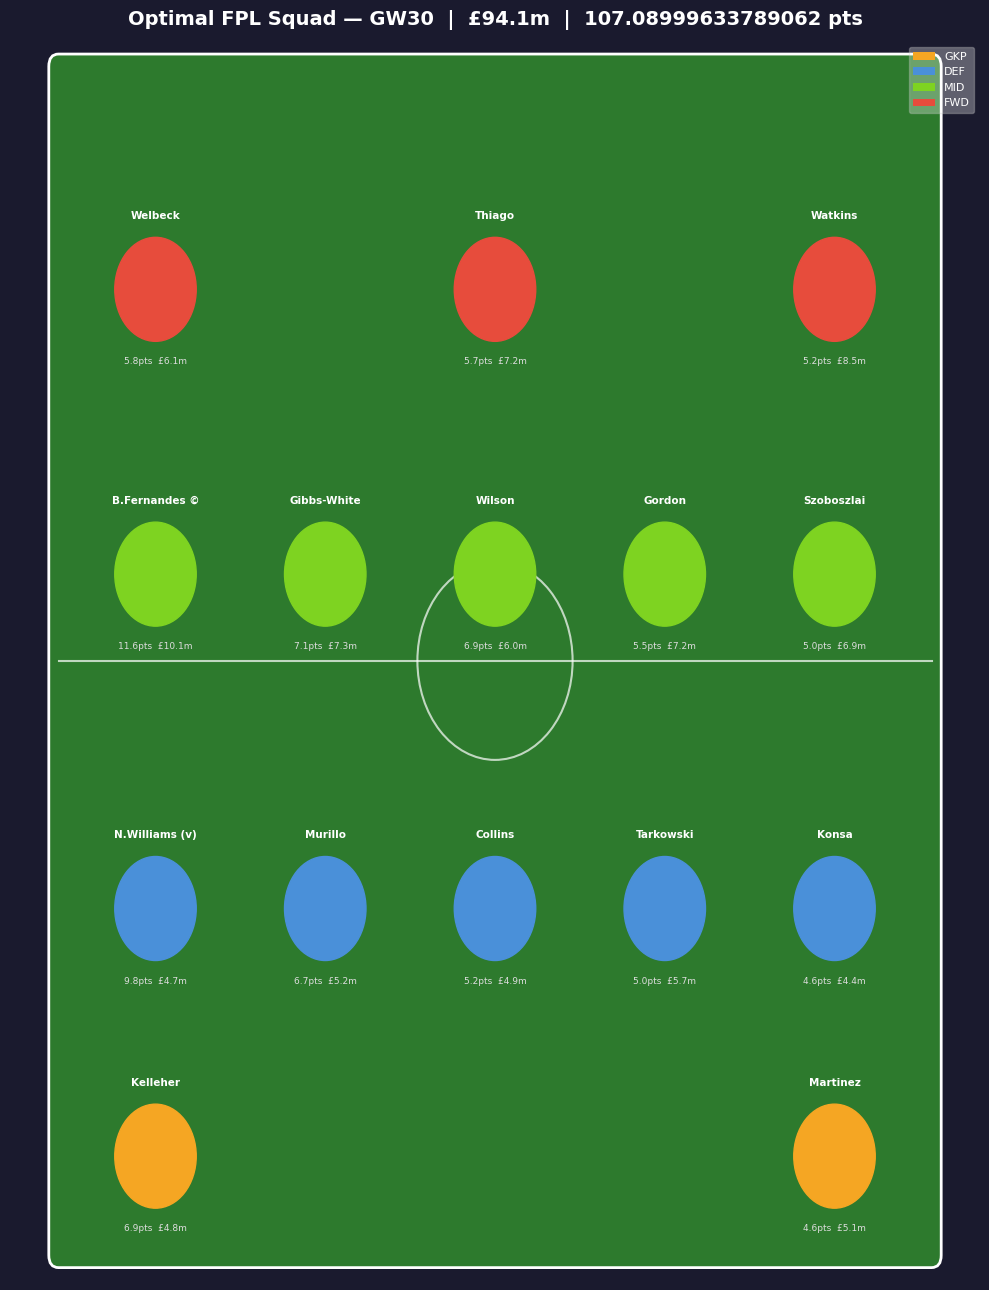

Saved to models/optimal_squad.png


In [18]:
def plot_squad_on_pitch(squad_df, captain_name, vice_name, title='Optimal FPL Squad'):
    """
    Draw a simple football pitch and place players by position.
    GKP at bottom, then DEF, MID, FWD rows.
    """
    fig, ax = plt.subplots(figsize=(10, 13))
    ax.set_facecolor('#2d7a2d')  # grass green
    fig.patch.set_facecolor('#1a1a2e')

    # Draw pitch lines
    pitch_rect = mpatches.FancyBboxPatch((0.05, 0.02), 0.90, 0.96,
                                          boxstyle='round,pad=0.01',
                                          linewidth=2, edgecolor='white',
                                          facecolor='#2d7a2d')
    ax.add_patch(pitch_rect)

    # Halfway line
    ax.axhline(y=0.5, xmin=0.05, xmax=0.95, color='white', linewidth=1.5, alpha=0.7)

    # Centre circle
    circle = plt.Circle((0.5, 0.5), 0.08, color='white', fill=False, linewidth=1.5, alpha=0.7)
    ax.add_patch(circle)

    # Position rows (y positions from bottom)
    row_y = {'GKP': 0.10, 'DEF': 0.30, 'MID': 0.57, 'FWD': 0.80}
    pos_colors = {'GKP': '#f5a623', 'DEF': '#4a90d9', 'MID': '#7ed321', 'FWD': '#e74c3c'}

    for pos, y in row_y.items():
        pos_players = squad_df[squad_df['position'] == pos].reset_index(drop=True)
        n = len(pos_players)
        xs = np.linspace(0.15, 0.85, n)

        for i, (_, player) in enumerate(pos_players.iterrows()):
            name = player['web_name']
            pts  = player['predicted_pts']
            cost = player['now_cost']
            color = pos_colors[pos]

            # Draw player circle
            circle = plt.Circle((xs[i], y), 0.042, color=color, zorder=5)
            ax.add_patch(circle)

            # Captain / VC badge
            badge = ''
            if name == captain_name:
                badge = ' ©'
            elif name == vice_name:
                badge = ' (v)'

            # Name label
            ax.text(xs[i], y + 0.055, f'{name}{badge}',
                    ha='center', va='bottom', fontsize=7.5,
                    color='white', fontweight='bold', zorder=6)

            # Points + cost
            ax.text(xs[i], y - 0.055, f'{pts:.1f}pts  £{cost}m',
                    ha='center', va='top', fontsize=6.5,
                    color='#dddddd', zorder=6)

    # Legend
    legend_elements = [mpatches.Patch(facecolor=c, label=p)
                       for p, c in pos_colors.items()]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=8, framealpha=0.3, labelcolor='white')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(title, color='white', fontsize=14, pad=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(MODELS / 'optimal_squad.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('Saved to models/optimal_squad.png')


plot_squad_on_pitch(
    squad_df,
    captain_name=result['captain'],
    vice_name=result['vice_captain'],
    title=f'Optimal FPL Squad — GW{latest_gw}  |  £{result["total_cost"]}m  |  {result["predicted_total"]} pts'
)

## 5. Transfer advisor

Given a manager's current squad, the transfer advisor evaluates every possible
1- and 2-player swap, respecting:
- Position constraints (like-for-like)
- Budget neutrality (sell price + bank)
- Club limit (max 3 per club)
- Transfer hit (−4 pts per transfer beyond free transfers)

The result is ranked by **net gain** = gross points gain − hit penalty.

In [29]:
# Build a realistic suboptimal squad to demonstrate the transfer advisor.
# We pick mid-table players per position — not the worst, not the best.
# In the real app this comes from the FPL API for the manager's actual squad.

def pick_suboptimal_squad(pool: pd.DataFrame, seed: int = 42) -> list[int]:
    """Pick a 15-man squad that is decent but not optimal, with no duplicates."""
    import numpy as np
    rng = np.random.default_rng(seed)
    picks = []
    used_ids = set()
    counts = {'GKP': 2, 'DEF': 5, 'MID': 5, 'FWD': 3}
    for pos, n in counts.items():
        pos_pool = (
            pool[pool['position'] == pos]
            .sort_values('predicted_pts', ascending=False)
        )
        # Skip the top quarter — take from the middle of the ranked list
        skip = max(1, len(pos_pool) // 4)
        candidates = pos_pool.iloc[skip:].copy()
        # Remove already-picked players
        candidates = candidates[~candidates['player_id'].isin(used_ids)]
        chosen = candidates.head(n)
        picks.extend(chosen['player_id'].tolist())
        used_ids.update(chosen['player_id'].tolist())
    return picks

current_squad_ids = pick_suboptimal_squad(players_available)
current_squad = players_available[players_available['player_id'].isin(current_squad_ids)]

print(f'Simulated current squad ({len(current_squad_ids)} players):')
for pos in ['GKP', 'DEF', 'MID', 'FWD']:
    players_in_pos = current_squad[current_squad['position'] == pos]
    names = ', '.join(players_in_pos['web_name'].tolist())
    print(f'  {pos}: {names}')

Simulated current squad (15 players):
  GKP: Hermansen, Ellborg
  DEF: Struijk, Shaw, Yoro, Pedro Porro, Hato
  MID: Schade, Schade, Yarmoliuk, Dewsbury-Hall, Barnes, Rayan
  FWD: Richarlison, Bowen, Šeško


In [27]:
# Recommend transfers with 1 free transfer and £1.0m in the bank
transfers = optimizer.recommend_transfers(
    current_squad_ids=current_squad_ids,
    players_df=players_available,
    free_transfers=1,
    bank=1.0,
)

one_t = [t for t in transfers if t['n_transfers'] == 1]
two_t = [t for t in transfers if t['n_transfers'] == 2]

print(f'Top {len(transfers)} transfer options returned (best by net gain):')
print(f'  1-transfer options : {len(one_t)}  (free, no hit)')
print(f'  2-transfer options : {len(two_t)}  (second costs −4 pts hit)')
print(f'  Profitable (net > 0): {sum(1 for t in transfers if t["net_gain"] > 0)}')

Top 20 transfer options returned (best by net gain):
  1-transfer options : 15  (free, no hit)
  2-transfer options : 5  (second costs −4 pts hit)
  Profitable (net > 0): 20


In [28]:
# Display top 10 recommended transfers
print('=== Top Transfer Recommendations ===')
print(f'{"#":<3} {"OUT":<20} {"pts":>7}  {"IN":<20} {"pts":>6}  {"Gross":>6} {"Hit":>4} {"Net":>6} {"£Δ":>6}')
print('-' * 85)

for i, t in enumerate(transfers[:10], 1):
    out_str = ', '.join(t['transfers_out'])
    in_str  = ', '.join(t['transfers_in'])
    rec     = ' ✓' if t['is_recommended'] else ''
    print(f'{i:<3} {out_str:<20} {t["out_pts"]:>7.2f}  {in_str:<20} {t["in_pts"]:>6.2f}  '
          f'{t["gross_gain"]:>6.2f} {t["hit"]:>4} {t["net_gain"]:>6.2f} '
          f'{t["cost_change"]:>+6.1f}m{rec}')

=== Top Transfer Recommendations ===
#   OUT                      pts  IN                      pts   Gross  Hit    Net     £Δ
-------------------------------------------------------------------------------------
1   Barnes                  2.53  Wilson                 6.89    4.36    0   4.36   -0.1m ✓
2   Dewsbury-Hall           2.57  Wilson                 6.89    4.32    0   4.32   +0.9m ✓
3   Yarmoliuk               2.68  Wilson                 6.89    4.21    0   4.21   +1.0m ✓
4   Rayan                   2.68  Wilson                 6.89    4.21    0   4.21   +0.4m ✓
5   Ellborg                 1.50  Sels                   5.44    3.95    0   3.95   +0.6m ✓
6   Hermansen               1.85  Sels                   5.44    3.60    0   3.60   +0.4m ✓
7   Barnes, Ellborg         4.03  Martinez, Wilson      11.48    7.45    4   3.45   +1.0m ✓
8   Bowen                   2.53  Igor Jesus             5.82    3.29    0   3.29   -1.7m ✓
9   Bowen                   2.53  Welbeck           

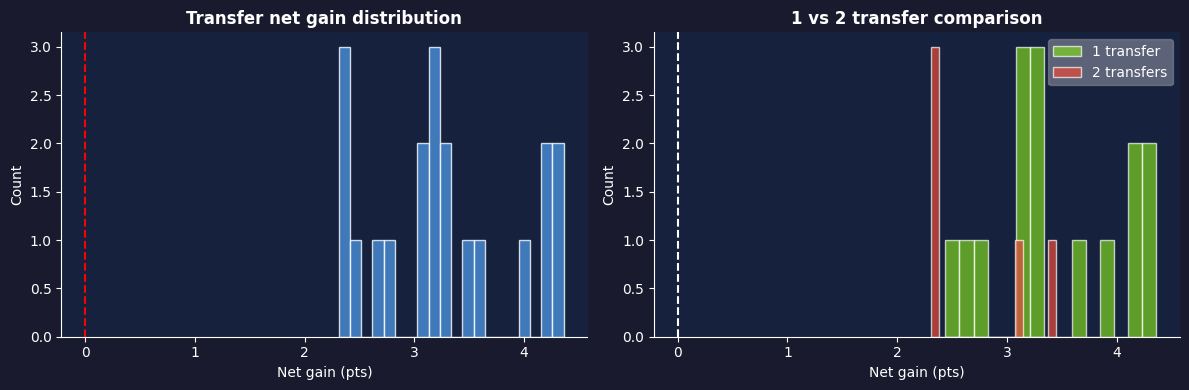

Saved to models/transfer_analysis.png


In [22]:
# Visualise the transfer gain distribution
net_gains = [t['net_gain'] for t in transfers]
n_transfers = [t['n_transfers'] for t in transfers]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Net gain distribution
axes[0].hist(net_gains, bins=20, color='#4a90d9', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Net gain (pts)', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].set_title('Transfer net gain distribution', color='white', fontweight='bold')

# 1-transfer vs 2-transfer breakdown
one_t = [t['net_gain'] for t in transfers if t['n_transfers'] == 1]
two_t = [t['net_gain'] for t in transfers if t['n_transfers'] == 2]

if one_t:
    axes[1].hist(one_t, bins=15, color='#7ed321', alpha=0.7, label='1 transfer', edgecolor='white')
if two_t:
    axes[1].hist(two_t, bins=15, color='#e74c3c', alpha=0.7, label='2 transfers', edgecolor='white')
axes[1].axvline(x=0, color='white', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Net gain (pts)', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].set_title('1 vs 2 transfer comparison', color='white', fontweight='bold')
axes[1].legend(labelcolor='white', framealpha=0.3)

plt.tight_layout()
plt.savefig(MODELS / 'transfer_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved to models/transfer_analysis.png')

## 6. Budget sensitivity analysis

How much does the predicted squad value improve as we increase the budget
from £85m to £105m? This helps understand the marginal value of spending.

In [23]:
budgets = np.arange(85, 106, 1.0)  # £85m to £105m in £1m steps
predicted_totals = []
total_costs      = []

for b in budgets:
    r = optimizer.select_squad(players_available, budget=float(b))
    if r['status'] == 'Optimal':
        predicted_totals.append(r['predicted_total'])
        total_costs.append(r['total_cost'])
    else:
        predicted_totals.append(None)
        total_costs.append(None)

print('Budget sensitivity:')
print(f'{"Budget":>8} | {"Cost":>6} | {"Pred pts":>9}')
print('-' * 30)
for b, c, p in zip(budgets, total_costs, predicted_totals):
    if p is not None:
        print(f'£{b:>5.0f}m  | £{c:>4.1f}m  | {p:>9.2f}')

Budget sensitivity:
  Budget |   Cost |  Pred pts
------------------------------
£   85m  | £85.0m  |    103.86
£   86m  | £85.9m  |    104.77
£   87m  | £86.7m  |    104.89
£   88m  | £88.0m  |    105.69
£   89m  | £88.9m  |    105.84
£   90m  | £89.4m  |    106.07
£   91m  | £90.6m  |    106.58
£   92m  | £90.6m  |    106.58
£   93m  | £92.9m  |    106.58
£   94m  | £94.0m  |    107.05
£   95m  | £94.1m  |    107.09
£   96m  | £94.1m  |    107.09
£   97m  | £94.1m  |    107.09
£   98m  | £94.1m  |    107.09
£   99m  | £94.1m  |    107.09
£  100m  | £94.1m  |    107.09
£  101m  | £94.1m  |    107.09
£  102m  | £94.1m  |    107.09
£  103m  | £94.1m  |    107.09
£  104m  | £94.1m  |    107.09
£  105m  | £94.1m  |    107.09


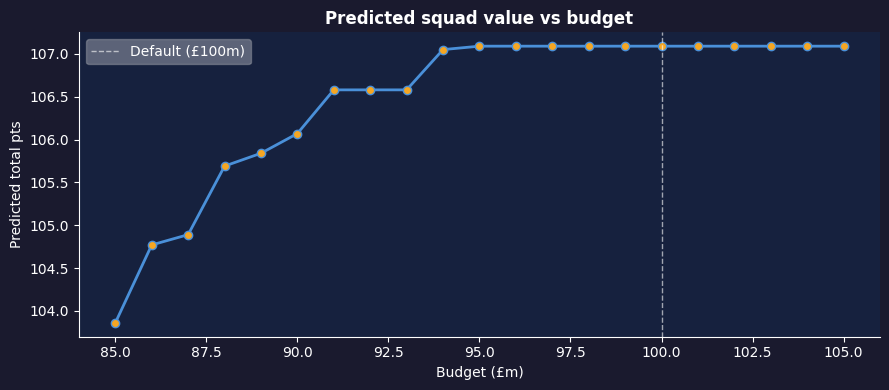

Saved to models/budget_sensitivity.png


In [24]:
valid = [(b, p) for b, p in zip(budgets, predicted_totals) if p is not None]
bx, py = zip(*valid)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

ax.plot(bx, py, marker='o', linewidth=2, color='#4a90d9',
        markersize=6, markerfacecolor='#f5a623')
ax.axvline(x=100, color='white', linestyle='--', linewidth=1, alpha=0.6, label='Default (£100m)')

ax.set_xlabel('Budget (£m)', color='white')
ax.set_ylabel('Predicted total pts', color='white')
ax.set_title('Predicted squad value vs budget', color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.legend(labelcolor='white', framealpha=0.3)
for spine in ax.spines.values():
    spine.set_edgecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODELS / 'budget_sensitivity.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved to models/budget_sensitivity.png')

## 7. Top value players (predicted pts per £m)

In [25]:
# Points per million — useful for finding differentials
players_with_preds = players_available[players_available['predicted_pts'] > 1.0].copy()
players_with_preds['pts_per_million'] = (
    players_with_preds['predicted_pts'] / players_with_preds['now_cost']
)

print('=== Top 15 value players (predicted pts per £m) ===')
top_value = players_with_preds.sort_values('pts_per_million', ascending=False).head(15)
print(top_value[['web_name', 'position', 'now_cost', 'predicted_pts', 'pts_per_million']]
      .to_string(index=False, float_format='{:.2f}'.format))

print()
print('=== Top 15 overall predicted scorers ===')
top_scorers = players_with_preds.sort_values('predicted_pts', ascending=False).head(15)
print(top_scorers[['web_name', 'position', 'now_cost', 'predicted_pts', 'pts_per_million']]
      .to_string(index=False, float_format='{:.2f}'.format))

=== Top 15 value players (predicted pts per £m) ===
   web_name position  now_cost  predicted_pts  pts_per_million
 N.Williams      DEF      4.70           9.85             2.10
   Kelleher      GKP      4.80           6.92             1.44
 Milenković      DEF      5.10           6.71             1.32
    Murillo      DEF      5.20           6.75             1.30
       Sels      GKP      4.60           5.44             1.18
     Wilson      MID      6.00           6.89             1.15
B.Fernandes      MID     10.10          11.55             1.14
       Aina      DEF      4.70           5.03             1.07
      Konsa      DEF      4.40           4.65             1.06
    Collins      DEF      4.90           5.16             1.05
      Rodon      DEF      3.90           3.96             1.02
      Bijol      DEF      3.90           3.95             1.01
 Igor Jesus      FWD      5.80           5.82             1.00
     Kayode      DEF      4.50           4.42             0.98
Gib

## 8. Summary

| Metric | Value |
|--------|-------|
| Optimizer | Integer Linear Programming (PuLP / CBC) |
| Squad size | 15 players |
| Constraints | Budget £100m, position counts, max 3 per club |
| Captain selection | Highest predicted pts in squad |
| Transfer advisor | All 1- and 2-player swaps, hit penalty = −4 pts/extra transfer |
| Budget sensitivity | Squad value increases non-linearly with budget |

The `FPLOptimizer` class in `src/models/optimize.py` is now ready to be
wired into the Dash application (Phase 7).